In [1]:
import duckdb

# PARQUET FILES ARE FROM https://huggingface.co/datasets/SII-WANGZJ/Polymarket_data BIG THANK YOU FOR ALL THE DATA

tradesPQ = 'X:/PolymarketData/trades.parquet'
marketPQ = 'X:/PolymarketData/markets.parquet'

marketlist = duckdb.query(f"SELECT condition_id FROM '{marketPQ}' WHERE VOLUME > 1000000 LIMIT 100")
conditionlist = marketlist.fetchall()
print(len(conditionlist))

100


In [2]:

# get initial db for further concats
market_df = duckdb.query(f"SELECT * FROM '{marketPQ}' WHERE condition_id = '{conditionlist[0][0]}'").to_df()
 # FOR SOME reason it outputs the list as a string so if "1" is at index 2 its index 0 as a list and 7 if in index 1]
winner = market_df['token1'].values[0] if market_df['outcome_prices'].values[0].index("1")== 2 else market_df['token2'].values[0]
df = duckdb.query(f"SELECT * FROM '{tradesPQ}' WHERE price > 0.1 AND price < 0.9 AND condition_id = '{conditionlist[0][0]}' ORDER BY RANDOM() LIMIT 1000").to_df()
df["won"] = (df["asset_id"] == winner).astype(int)


In [3]:
import pandas as pd


for markets in conditionlist[1:]:
    add_market_df = duckdb.query(f"SELECT * FROM '{marketPQ}' WHERE condition_id = '{markets[0]}'").to_df()
    if "'1'" not in add_market_df['outcome_prices'].values[0]:
        continue
    winner = add_market_df['token1'].values[0] if add_market_df['outcome_prices'].values[0].index("1")== 2 else add_market_df['token2'].values[0]

    add_df = duckdb.query(f"SELECT * FROM '{tradesPQ}' WHERE price > 0.1 AND price < 0.9 AND condition_id = '{markets[0]}' ORDER BY RANDOM() LIMIT 1000").to_df()
    if add_df.empty:
        continue
    add_df["won"] = (add_df["asset_id"] == winner).astype(int) 
    df = pd.concat([df,add_df],axis=0)
    market_df = pd.concat([market_df,add_market_df],axis = 0)
    print(df.shape)
print(market_df.shape)

(2000, 18)
(3000, 18)
(4000, 18)
(5000, 18)
(6000, 18)
(7000, 18)
(8000, 18)
(9000, 18)
(10000, 18)
(11000, 18)
(12000, 18)
(13000, 18)
(14000, 18)
(15000, 18)
(16000, 18)
(17000, 18)
(18000, 18)
(19000, 18)
(19617, 18)
(20617, 18)
(21617, 18)
(22617, 18)
(23617, 18)
(24617, 18)
(25617, 18)
(26617, 18)
(27617, 18)
(28617, 18)
(29617, 18)
(30617, 18)
(31617, 18)
(32617, 18)
(33617, 18)
(34617, 18)
(34628, 18)
(35628, 18)
(36628, 18)
(37628, 18)
(38628, 18)
(39628, 18)
(40628, 18)
(41628, 18)
(42628, 18)
(43628, 18)
(44628, 18)
(45628, 18)
(46628, 18)
(47628, 18)
(48628, 18)
(49628, 18)
(50628, 18)
(51628, 18)
(52628, 18)
(53628, 18)
(54628, 18)
(55628, 18)
(56628, 18)
(57628, 18)
(58628, 18)
(59628, 18)
(60628, 18)
(61628, 18)
(62628, 18)
(64, 20)


In [4]:
df = df.merge(market_df, on='condition_id', how='left')

In [5]:
df['end_date'] = pd.to_datetime(df['end_date'], format='ISO8601') ## endDate -> datetime
df['end_date'] = df['end_date'].apply(lambda x: x.timestamp() if pd.notna(x) else None )  ## datetime -> timestamp
df = df.dropna(subset=['end_date']) #drop if endDate is Na (about 1% of them)

df['created_at'] = pd.to_datetime(df['created_at'], format='ISO8601') ## endDate -> datetime
df['created_at'] = df['created_at'].apply(lambda x: x.timestamp() if pd.notna(x) else None )  ## datetime -> timestamp
df = df.dropna(subset=['created_at']) 


In [6]:
df['start_to_trade'] = (df['timestamp'] - df['created_at'])
df['trade_to_end'] = (df['end_date'] - df['timestamp'])
df['relativeSizeUSD'] = (df['usd_amount']/df['volume'])
df['relativeSizeToken'] = (df['token_amount']/df['volume'])
df['confidenceShowUSD'] = (df['usd_amount']/(1-df['price']))
df['confidenceShowToken'] = (df['token_amount']/(1-df['price']))
df['hour_of_day'] = pd.to_datetime(df['timestamp'], unit='s').dt.hour
df = df.sort_values(['condition_id', 'timestamp'])
df['market_avg_size_so_far'] = df.groupby('condition_id')['usd_amount'].transform(
    lambda x: x.expanding().mean().shift(1)  # shift(1) excludes current trade
)

def count_trades_in_window(df, t=3600):
    df = df.sort_values('timestamp').copy()
    df['window_trade_count'] = 0
    
    for id, group in df.groupby('condition_id'):
        timestamps = group['timestamp'].values
        counts = [(timestamps >= ts - t).sum() 
                  for ts in timestamps]
        df.loc[group.index, 'window_trade_count'] = counts
    
    return df

df = count_trades_in_window(df)

In [7]:
print(df.describe())

          timestamp  block_number     log_index         price     usd_amount  \
count  6.262800e+04  6.262800e+04  62628.000000  62628.000000   62628.000000   
mean   1.773774e+09  8.433843e+07   1667.004327      0.482256     115.588809   
std    4.943548e+06  2.423111e+06   1027.398784      0.196242    1152.769191   
min    1.752137e+09  7.380737e+07      4.000000      0.101000       0.000000   
25%    1.774053e+09  8.446641e+07    907.000000      0.340000       2.317500   
50%    1.775321e+09  8.510066e+07   1461.000000      0.480000       6.820000   
75%    1.775937e+09  8.540837e+07   2175.000000      0.610000      30.412500   
max    1.776226e+09  8.555297e+07   7395.000000      0.899999  107565.610000   

        token_amount           won   closed   active  archived  ...  \
count   62628.000000  62628.000000  62628.0  62628.0   62628.0  ...   
mean      234.861996      0.489478      1.0      1.0       0.0  ...   
std      2302.238094      0.499893      0.0      0.0       0.0  ..

                        timestamp     price  usd_amount  token_amount  \
timestamp                1.000000 -0.034469   -0.011860     -0.009091   
price                   -0.034469  1.000000    0.036562      0.005147   
usd_amount              -0.011860  0.036562    1.000000      0.963866   
token_amount            -0.009091  0.005147    0.963866      1.000000   
won                     -0.016008  0.410872    0.014006      0.001752   
volume                   0.033134 -0.006175    0.009493      0.012180   
start_to_trade          -0.204992  0.032230   -0.002540     -0.004576   
trade_to_end            -0.097639  0.032998   -0.000360     -0.003285   
relativeSizeUSD         -0.014093  0.030416    0.943287      0.899922   
relativeSizeToken       -0.012224  0.008218    0.923656      0.923026   
confidenceShowUSD       -0.025480  0.084126    0.931974      0.834401   
confidenceShowToken     -0.019172  0.052050    0.986781      0.945454   
created_at               0.928609 -0.041548   -0.00

Text(0.5, 1.0, 'Feature Correlation Matrix')

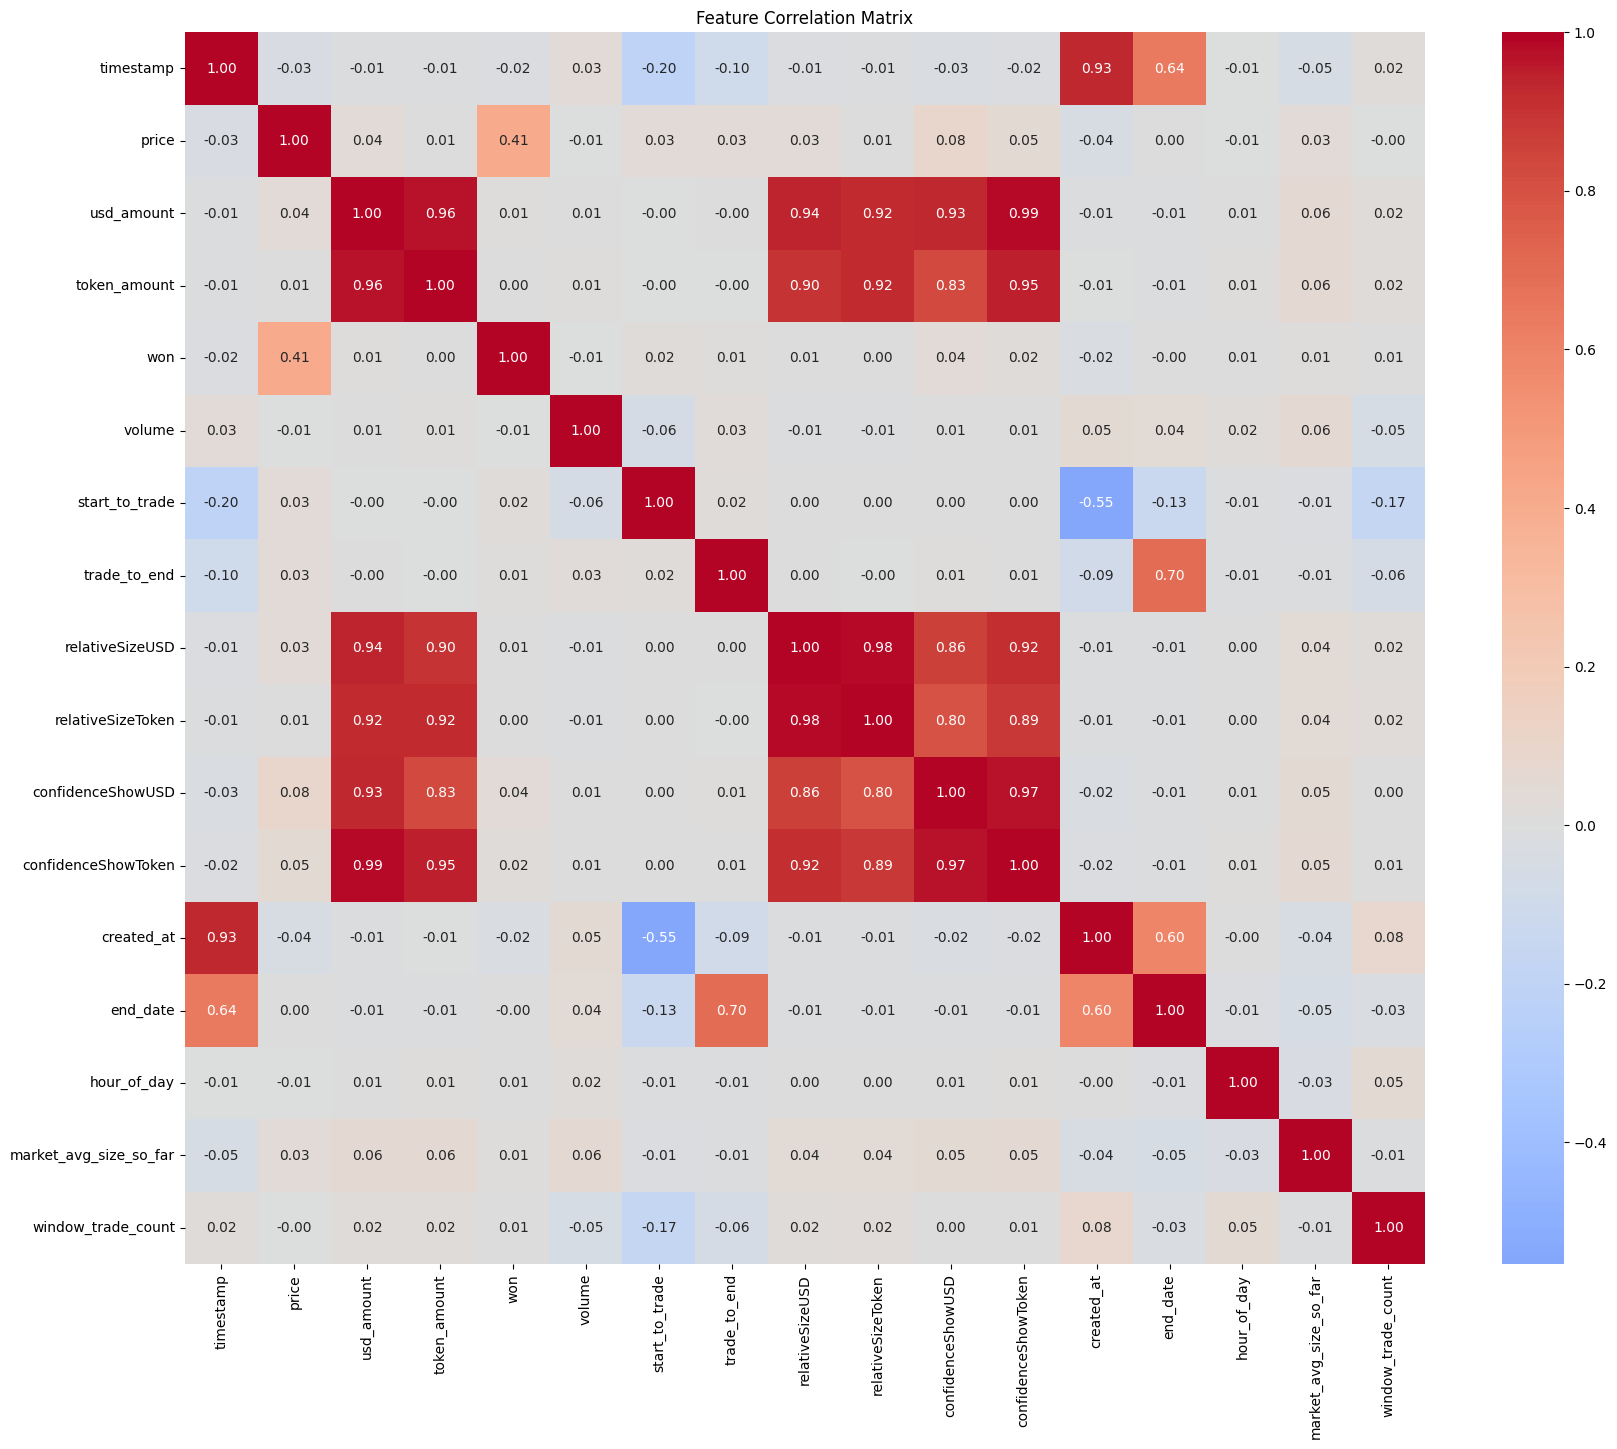

In [9]:
from matplotlib import pyplot as plt
import seaborn as sns

corr_matrix = df[['timestamp','price','usd_amount','token_amount','won','volume','start_to_trade','trade_to_end','relativeSizeUSD',
                  'relativeSizeToken','confidenceShowUSD','confidenceShowToken','created_at','end_date','hour_of_day','market_avg_size_so_far',
                  'window_trade_count']].corr()
print(corr_matrix)

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            annot=True,      # show values
            fmt='.2f',       # 2 decimal places
            cmap='coolwarm', # red to blue
            center=0)        # center colormap at 0

plt.title('Feature Correlation Matrix')